# 03 — Analyse Exploratoire : Chômage, Inactivité & Genre

### Objectif de ce notebook
Explorer les dynamiques de vulnérabilité des jeunes ivoiriens
selon trois dimensions : **niveau d'éducation**, **genre** et **secteur**.

**Questions auxquelles ce notebook répond :**
- Quel profil éducatif est le plus exposé au chômage ?
- Les femmes sont-elles structurellement plus inactives que les hommes ?
- Quels secteurs concentrent le plus grand nombre de jeunes ?

In [2]:
# IMPORTS

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import os

In [3]:
# LOAD DATA

path_processed = os.path.join('..', 'data', 'processed')
df = pd.read_csv(os.path.join(path_processed, 'ci_education_15_35.csv'))
df_sector_ci = pd.read_csv('../data/processed/ci_sector_15_35.csv')


In [4]:
print(df['genre'].unique())

<StringArray>
['female', 'male']
Length: 2, dtype: str


In [5]:
# COUNTRY FILTER CHECK

print("\n=== COUNTRY CHECK ===")
print(df['code_pays'].value_counts())

ci_values = ['CIV', "Cote d'Ivoire", "Ivory Coast"]

non_ci = df[~df['code_pays'].isin(ci_values)]

print("\n=== NON-COTE D'IVOIRE ROWS ===")
print(non_ci.shape[0])
print(non_ci['code_pays'].unique())

# Optional safety stop (useful during debugging)
if non_ci.shape[0] > 0:
    print("\n⚠ WARNING: Dataset is not strictly filtered to Côte d'Ivoire")


=== COUNTRY CHECK ===
code_pays
CIV    330
Name: count, dtype: int64

=== NON-COTE D'IVOIRE ROWS ===
0
<StringArray>
[]
Length: 0, dtype: str


### Indice de vulnérabilité
On construit un indicateur composite qui mesure
la part des jeunes **hors emploi productif** :

> `vulnerability = share_unemp + share_inact`

Une valeur de `0.65` signifie que **65% des jeunes
de ce groupe** sont soit au chômage, soit inactifs.

In [6]:
# FEATURE IMPORTANTE : VULNERABILITY

df['vulnerability'] = df['share_unemp'] + df['share_inact']


In [7]:
# LATEST YEAR SNAPSHOT

latest_year = df['annee'].max()

df_now = df[
    df['annee'] == latest_year
]

print("\nAnalyzed Year:", latest_year)


Analyzed Year: 2025


### Analyse 1 — Chômage par éducation et genre (2025)
On observe les taux de chômage pour chaque niveau
d'éducation, désagrégés par genre.

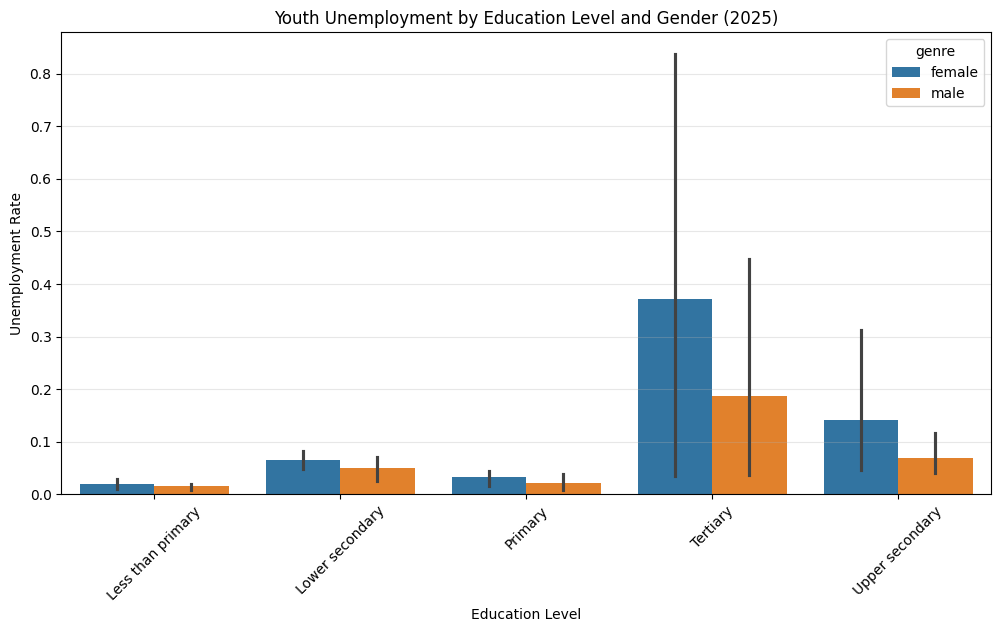

In [8]:
# ANALYSIS 1 — YOUTH UNEMPLOYMENT BY EDUCATION AND GENDER

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_now,
    x='edu_ilo',
    y='share_unemp',
    hue='genre'
)

plt.title(
    f"Youth Unemployment by Education Level and Gender ({latest_year})"
)

plt.xlabel("Education Level")
plt.ylabel("Unemployment Rate")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.show()

### Analyse 2 — Inactivité par éducation et genre (2025)
L'inactivité révèle les jeunes **découragés ou exclus**
du marché du travail — une dimension invisible du chômage officiel.

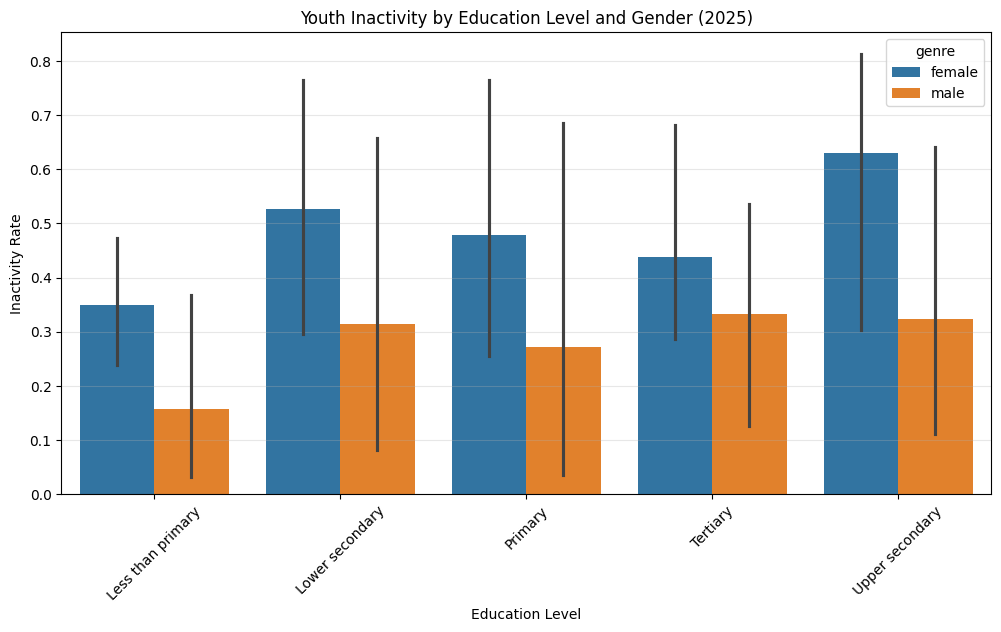

In [ ]:
# ANALYSIS 2 — YOUTH INACTIVITY

plt.figure(figsize=(12, 6))

sns.barplot(
    data=df_now,
    x='edu_ilo',
    y='share_inact',
    hue='genre'
)

plt.title(
    f"Youth Inactivity by Education Level and Gender ({latest_year})"
)

plt.xlabel("Education Level")
plt.ylabel("Inactivity Rate")

plt.xticks(rotation=45)

plt.grid(axis='y', alpha=0.3)

plt.show()

### Analyse 3 — Vulnérabilité globale
Vision consolidée : chômage + inactivité combinés.
C'est l'indicateur le plus complet pour mesurer
l'exclusion des jeunes du marché du travail.

> **Paradoxe clé** : les jeunes ayant atteint
> le niveau **tertiaire** affichent la vulnérabilité
> la plus élevée — l'éducation supérieure ne protège
> pas du chômage en Côte d'Ivoire.

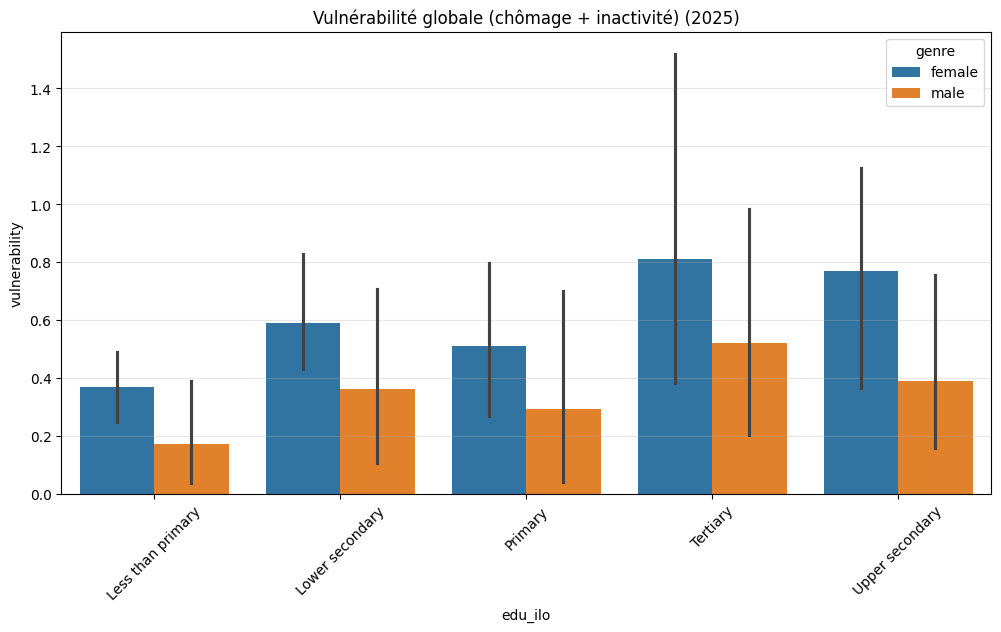

In [ ]:
# ANALYSE 3 — VULNÉRABILITÉ GLOBALE

plt.figure(figsize=(12,6))

sns.barplot(
    data=df_now,
    x='edu_ilo',
    y='vulnerability',
    hue='genre'
)

plt.title(f"Vulnérabilité globale (chômage + inactivité) ({latest_year})")
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.show()

### Analyse 4 — Tendance temporelle 2015–2025
Évolution du chômage et de l'inactivité sur 10 ans.

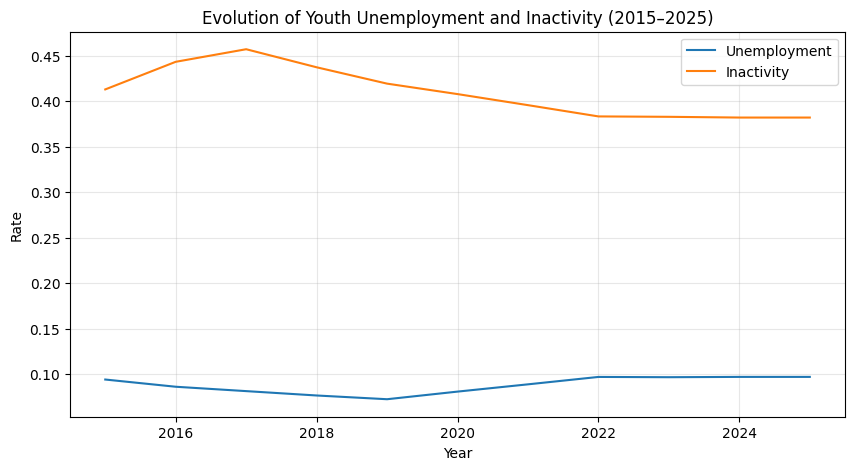

In [ ]:
# ANALYSIS 4 — TEMPORAL TREND ANALYSIS

df_trend = (
    df.groupby('annee')[['share_unemp', 'share_inact']]
    .mean()
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.lineplot(
    data=df_trend,
    x='annee',
    y='share_unemp',
    label='Unemployment'
)

sns.lineplot(
    data=df_trend,
    x='annee',
    y='share_inact',
    label='Inactivity'
)

plt.title("Evolution of Youth Unemployment and Inactivity (2015–2025)")
plt.xlabel("Year")
plt.ylabel("Rate")

plt.grid(alpha=0.3)

plt.legend()

plt.show()

In [ ]:
#  INSIGHT RAPIDE (NUMÉRIQUE)

print("\n=== INSIGHT GLOBAL ===")
print(df_now.groupby('edu_ilo')[['share_unemp', 'share_inact', 'vulnerability']].mean())


=== INSIGHT GLOBAL ===
                   share_unemp  share_inact  vulnerability
edu_ilo                                                   
Less than primary     0.017802     0.253429       0.271231
Lower secondary       0.057182     0.420798       0.477980
Primary               0.026717     0.374903       0.401620
Tertiary              0.279765     0.385386       0.665151
Upper secondary       0.104669     0.476513       0.581183


### Analyse 5 — Structure sectorielle de l'emploi
Identification des 10 secteurs qui concentrent
le plus grand nombre de jeunes ivoiriens.

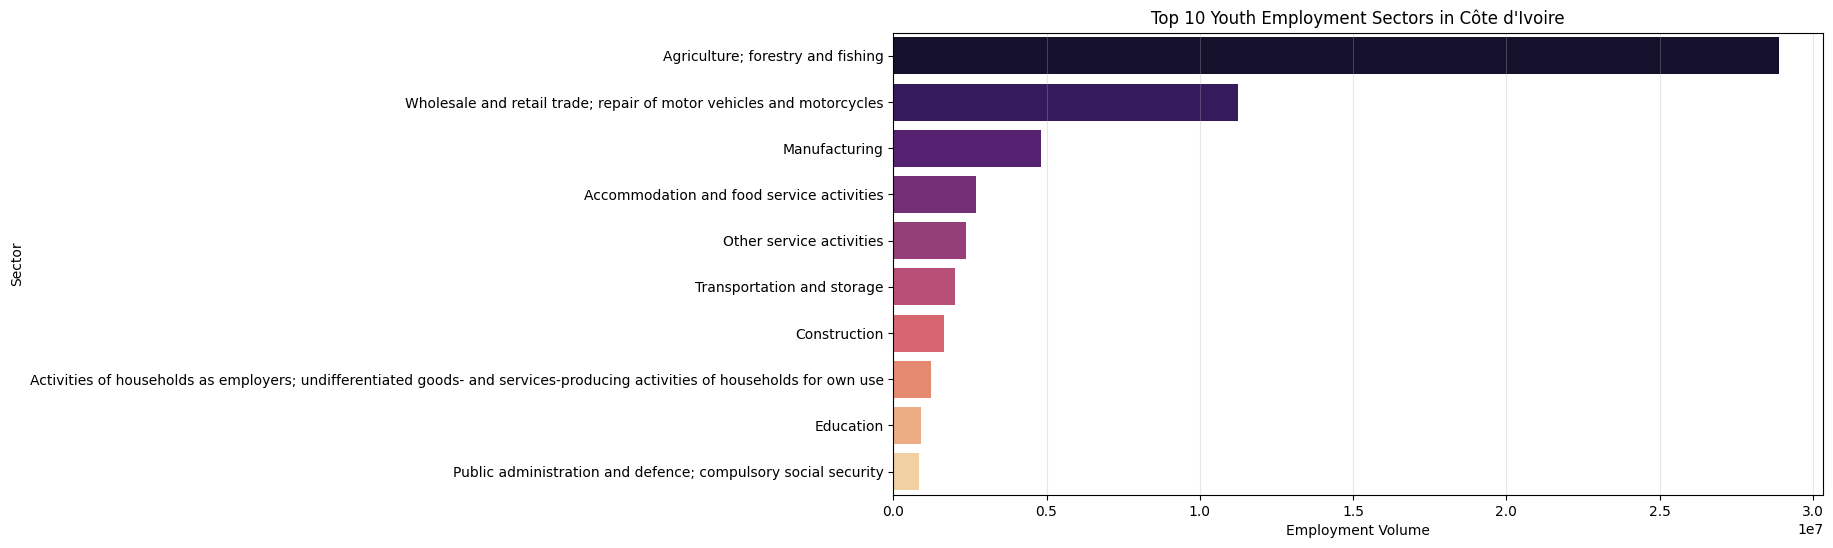

In [ ]:
# TOP EMPLOYMENT SECTORS

sector_dist = (
    df_sector_ci.groupby('sector21')['population']
    .sum()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=sector_dist,
    x='population',
    y='sector21',
    hue='sector21',
    legend=False,
    palette='magma'
)

plt.title("Top 10 Youth Employment Sectors in Côte d'Ivoire")
plt.xlabel("Employment Volume")
plt.ylabel("Sector")

plt.grid(axis='x', alpha=0.3)

plt.show()

### Analyse 6 — Répartition par genre dans les secteurs clés
Certains secteurs sont massivement masculins (agriculture, construction),
d'autres plus féminins (éducation, services).
Cet écart révèle une **ségrégation sectorielle de genre**.

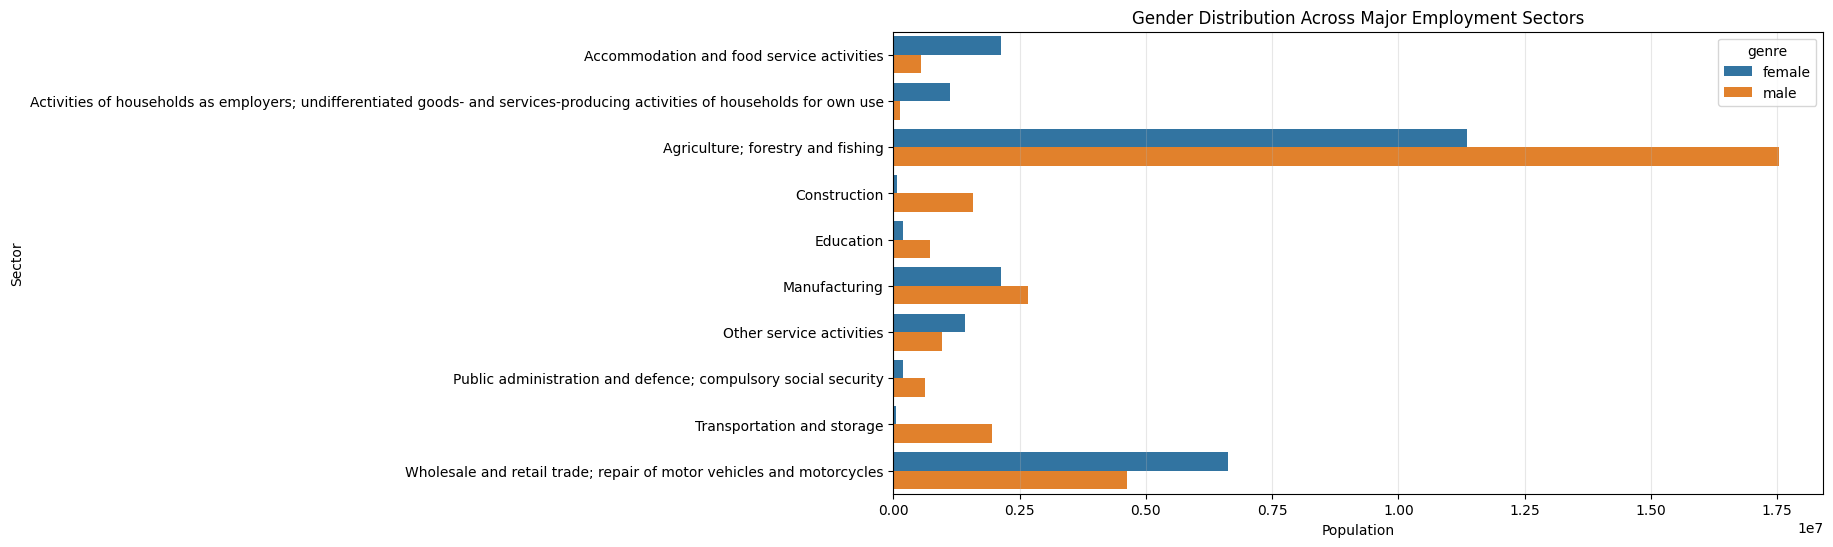

In [ ]:
# GENDER DISTRIBUTION ACROSS KEY SECTORS

top_sectors = sector_dist['sector21'].tolist()

df_top = df_sector_ci[
    df_sector_ci['sector21'].isin(top_sectors)
]

sector_gender = (
    df_top.groupby(['sector21', 'genre'])['population']
    .sum()
    .reset_index()
)

plt.figure(figsize=(12, 6))

sns.barplot(
    data=sector_gender,
    x='population',
    y='sector21',
    hue='genre'
)

plt.title("Gender Distribution Across Major Employment Sectors")
plt.xlabel("Population")
plt.ylabel("Sector")

plt.grid(axis='x', alpha=0.3)

plt.show()

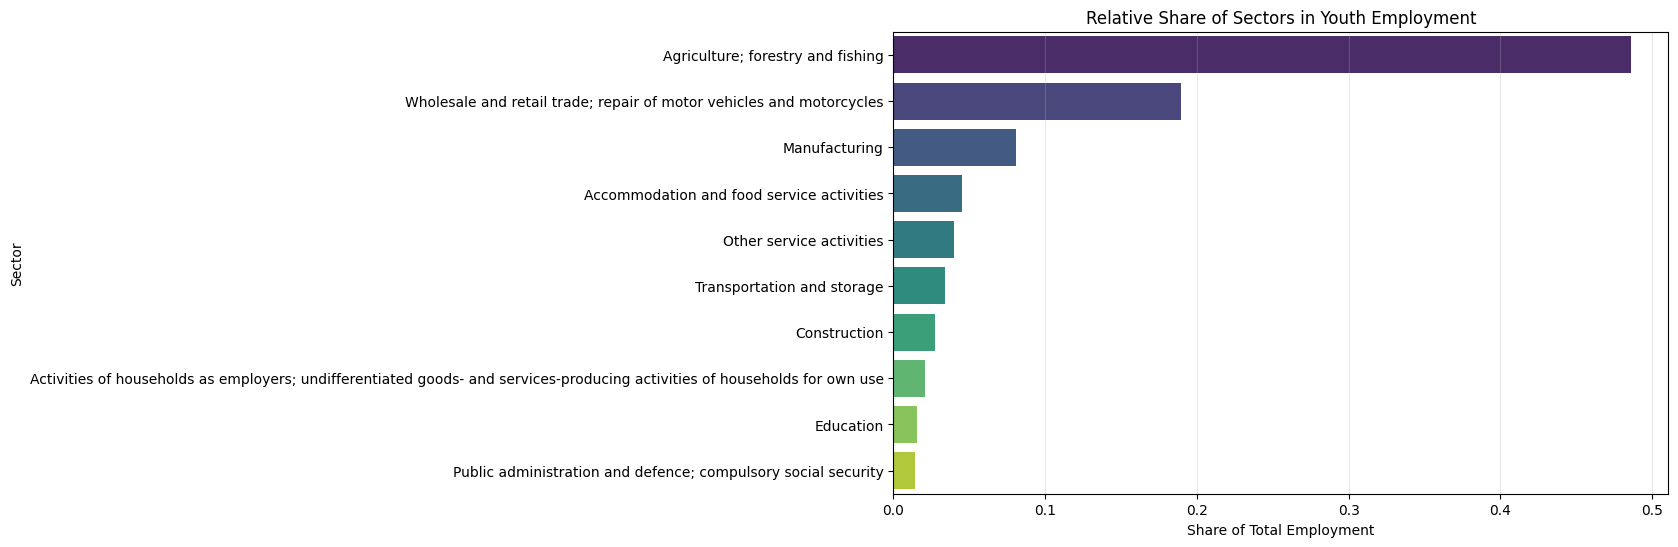

In [ ]:
# CRITICAL STRUCTURAL ANALYSIS

sector_share = (
    df_sector_ci.groupby('sector21')['population']
    .sum()
    .reset_index()
)

sector_share['share'] = (
    sector_share['population'] / sector_share['population'].sum()
)

sector_share = sector_share.sort_values('share', ascending=False)

plt.figure(figsize=(10, 6))

sns.barplot(
    data=sector_share.head(10),
    x='share',
    y='sector21',
    hue='sector21',
    legend=False,
    palette='viridis'
)

plt.title("Relative Share of Sectors in Youth Employment")
plt.xlabel("Share of Total Employment")
plt.ylabel("Sector")
plt.grid(axis='x', alpha=0.3)

plt.show()

In [ ]:
# STATISTICAL INSIGHT

print("\n=== EMPLOYMENT CONCENTRATION ===")
print(sector_share.head(10))

print("\n=== INTERPRETATION ===")
print("""
- If a few sectors dominate strongly → the economy is weakly diversified
- If employment distribution is balanced → the economy is more resilient
""")


=== EMPLOYMENT CONCENTRATION ===
                                             sector21  population     share
4                   Agriculture; forestry and fishing  28897468.0  0.486310
20  Wholesale and retail trade; repair of motor ve...  11249038.0  0.189308
12                                      Manufacturing   4804207.0  0.080849
0           Accommodation and food service activities   2692696.0  0.045315
14                           Other service activities   2369389.0  0.039874
18                         Transportation and storage   2016180.0  0.033930
6                                        Construction   1650030.0  0.027768
2   Activities of households as employers; undiffe...   1244720.0  0.020947
7                                           Education    910465.0  0.015322
16  Public administration and defence; compulsory ...    834494.0  0.014044

=== INTERPRETATION ===

- If a few sectors dominate strongly → the economy is weakly diversified
- If employment distribution is 

### Conclusion
Trois constats structurels émergent de cette analyse :

1. **Le paradoxe du diplômé** — la vulnérabilité croît avec le niveau
   d'éducation, signe d'un marché du travail inadapté
2. **L'exclusion féminine** — les femmes sont systématiquement
   plus inactives que les hommes à tous les niveaux d'éducation
3. **La concentration informelle** — agriculture et commerce
   représentent 68% de l'emploi des jeunes

